<a href="https://www.kaggle.com/code/mikematician/neural-ode-continious-normalizing-flow?scriptVersionId=313904395" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

<a href="https://www.kaggle.com/code/mikematician/neural-ode-continious-normalizing-flow?scriptVersionId=313689071" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# Neural ODE / Continious Normalizing Flow from Scratch

try:
- smaller regularization
- smaller model
- more training steps

In [41]:
import torch
import torch.optim as optim
import torch.nn as nn
from torch.utils.data import DataLoader, random_split
from torchinfo import summary

import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_circles, make_moons

# if nvidia gpu available use it
device = "cuda" if torch.cuda.is_available() else "cpu"

print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("CUDA version:", torch.version.cuda)
    print("Device:", torch.cuda.get_device_name(0))
    print("Compute capability:", torch.cuda.get_device_capability(0))
    print("Supported archs:", torch.cuda.get_arch_list())

PyTorch: 2.10.0+cu128
CUDA available: True
CUDA version: 12.8
Device: Tesla T4
Compute capability: (7, 5)
Supported archs: ['sm_70', 'sm_75', 'sm_80', 'sm_86', 'sm_90', 'sm_100', 'sm_120']


## 1. Generate Toy Datasets

In [42]:
# generate moon dataset
coord_moon, label_moon = make_moons(1000, noise=0.025)

# generate circle dataset 
coord_circle, label_circle = make_circles(1000, noise=0.025, factor=0.5)

# dtype of dataset
print(type(coord_circle))

# dimension of data
print(coord_circle.shape)
print(label_circle.shape)

print(coord_circle[0])

<class 'numpy.ndarray'>
(1000, 2)
(1000,)
[0.47816257 0.03913409]


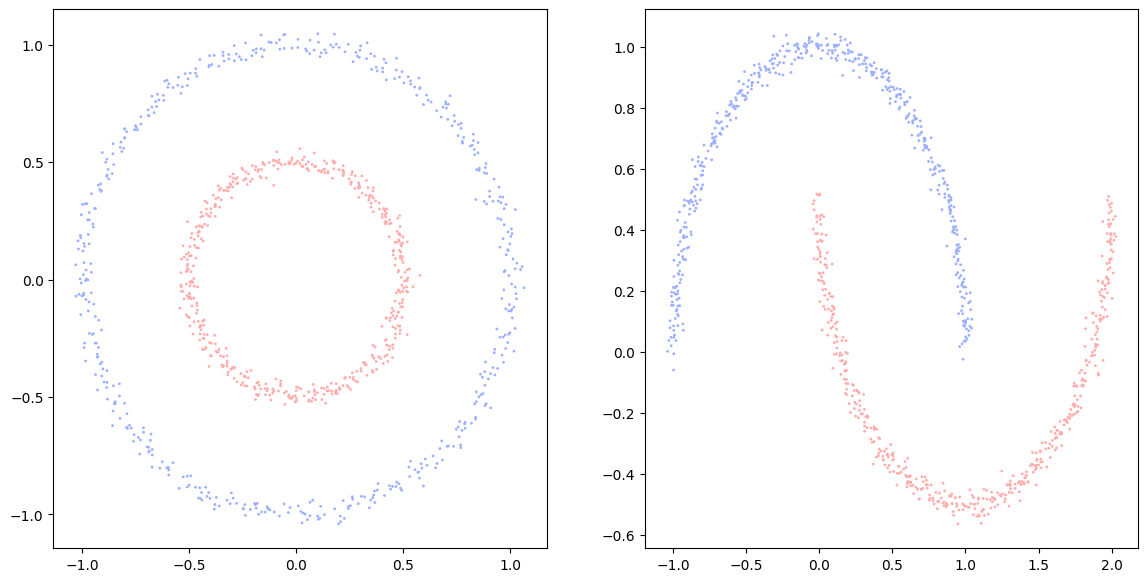

In [43]:
# plot datasets
fig, ax = plt.subplots(1, 2, figsize=(14, 7))

# plot circle data
ax[0].scatter(coord_circle[... , 0], coord_circle[... , 1], s=1, c=label_circle, cmap="berlin")

# plot moon data
ax[1].scatter(coord_moon[... , 0], coord_moon[... , 1], s=1, c=label_moon, cmap="berlin")

In [44]:
# Turn circle data into tensor dataset
x_circle = coord_circle[..., 0]
y_circle = coord_circle[..., 1]

circle_numpy = np.array([x_circle, y_circle])
circle_tensor = torch.from_numpy(circle_numpy).float().T
print(circle_tensor.shape)

# Turn moon data into tensor dataset
x_moon = coord_moon[..., 0]
y_moon = coord_moon[..., 1]

moon_numpy = np.array([x_moon, y_moon])
moon_tensor = torch.from_numpy(moon_numpy).float().T
print(moon_tensor.shape)

torch.Size([1000, 2])
torch.Size([1000, 2])


## 2. ODE-Solver

### 2.1 Euler Method

In [45]:
# one step of euler method
def euler_step(dynamic, y_n, t_n, step_size):
    step = y_n + step_size * dynamic(y_n, t_n)
    return step


# euler ode solver
def euler_solver(dynamic, y_0, t_0, nb_steps, step_size):
    y_n, t_n = y_0, t_0

    # calculate steps until endstep
    for _ in range(nb_steps):
        y_n = euler_step(dynamic, y_n, t_n, step_size)
        t_n = t_n + step_size
    
    return y_n, t_n

### 2.2 Runge-Kutta method (RK4)

In [46]:
# one step of Runge-Kutta (RK4)
def rk4_step(dynamic, y_n, t_n, stepsize):
    # calculate k_n for n in [1, 2, 3, 4] for weighted average of the four increments
    k_1 = dynamic(y_n, t_n)
    k_2 = dynamic(y_n + k_1 * stepsize / 2, t_n + stepsize / 2)
    k_3 = dynamic(y_n + k_2 * stepsize / 2, t_n + stepsize / 2)
    k_4 = dynamic(y_n + stepsize * k_3, t_n + stepsize)

    # calculate step
    step = y_n + stepsize / 6 * (k_1 + 2*k_2 + 2*k_3 + k_4)
    return step

# Runge-Kutta ode solver
def rk4_solver(model, y_0, t_0, nb_steps, step_size):
    y_n, t_n = y_0, t_0

    # calculate steps until endstep
    for _ in range(nb_steps):
        y_n = rk4_step(model, y_n, t_n, step_size)
        t_n = t_n + step_size
    
    return y_n, t_n

### 2.3 Test ODE Solver

In [47]:
# analytical solution
# dy/dt = -y, y(t) = y_0 * exp(-t)
# dy/dt = 2t, y(t) = y_0 + t^2

def model_exp(y, t):
    """dy/dt = -y"""
    return -y

def model_linear(y, t):
    """dy/dt = 2"""
    return 2

In [48]:
# testing euler 
# case exp decay
y_0_exp = torch.tensor(1.0)
y_end_exp = euler_solver(model_exp, y_0_exp, t_0=0.0, nb_steps=1000, step_size=0.001)
expected_exp = torch.exp(torch.tensor(-1.0))

# case linear function
y_0_linear = torch.tensor(1.0)
y_end_linear = euler_solver(model_linear, y_0_linear, t_0=0.0, nb_steps=1000, step_size=0.001)
expected_linear = y_0_linear + 2

# case 2D input
y_0_2D = torch.ones(8, 2)
y_end_2D = euler_solver(model_exp, y_0_2D, t_0=0.0, nb_steps=10, step_size=0.1)

print(f"exp true: {expected_exp}, solver: {y_end_exp}")
print(f"linear true: {expected_linear}, solver: {y_end_linear}")
print(f"solver 2D: {y_end_2D}")

exp true: 0.3678794503211975, solver: (tensor(0.3677), 1.0000000000000007)
linear true: 3.0, solver: (tensor(3.0000), 1.0000000000000007)
solver 2D: (tensor([[0.3487, 0.3487],
        [0.3487, 0.3487],
        [0.3487, 0.3487],
        [0.3487, 0.3487],
        [0.3487, 0.3487],
        [0.3487, 0.3487],
        [0.3487, 0.3487],
        [0.3487, 0.3487]]), 0.9999999999999999)


In [49]:
# testing rk4 
# case exp decay
y_0_exp = torch.tensor(1.0)
y_end_exp = rk4_solver(model_exp, y_0_exp, t_0=0.0, nb_steps=1000, step_size=0.001)
expected_exp = torch.exp(torch.tensor(-1.0))

# case linear function
y_0_linear = torch.tensor(1.0)
y_end_linear = rk4_solver(model_linear, y_0_linear, t_0=0.0, nb_steps=1000, step_size=0.001)
expected_linear = y_0_linear + 2

# case 2D input
y_0_2D = torch.ones(8, 2)
y_end_2D = rk4_solver(model_exp, y_0_2D, t_0=0.0, nb_steps=10, step_size=0.1)

print(f"exp true: {expected_exp}, solver: {y_end_exp}")
print(f"linear true: {expected_linear}, solver: {y_end_linear}")
print(f"solver 2D: {y_end_2D}")

exp true: 0.3678794503211975, solver: (tensor(0.3679), 1.0000000000000007)
linear true: 3.0, solver: (tensor(3.0000), 1.0000000000000007)
solver 2D: (tensor([[0.3679, 0.3679],
        [0.3679, 0.3679],
        [0.3679, 0.3679],
        [0.3679, 0.3679],
        [0.3679, 0.3679],
        [0.3679, 0.3679],
        [0.3679, 0.3679],
        [0.3679, 0.3679]]), 0.9999999999999999)


## 3. Adjoint-based Backpropagation 

### 3.1 Custom Autograd Function for Adjoint Method

In [50]:
# custom autograd.Function s.t. pytorch does not calculate computational graph for autograd
class AdjointSolver(torch.autograd.Function):

    # to make calculation of trace cheaper and more stable we use vjp and Hutchinson-Trace-Estimation (Monte-Carlo-Mothod)
    @staticmethod
    def hutchinson_trace_estimate(dz_dt, z, n_samples=1, create_graph=False, retain_graph=False):
        trace = torch.zeros(z.shape[0], device=z.device)
        for i in range(n_samples):
            v = torch.ones_like(z)
            v[torch.rand_like(z) < 0.5] = -1
            keep = True if i < n_samples - 1 else retain_graph
            vjp = torch.autograd.grad(dz_dt, z, grad_outputs=v, create_graph=create_graph, retain_graph=keep)[0]
            trace += (vjp * v).sum(dim=-1)
        return trace / n_samples


    # create function to build system of ODEs
    @staticmethod
    def _augmented_dynamics(model, state, t, batch_size, detach_output=True):
        z_0 = state[:, :-1]

        # calculate gradient for trace
        with torch.enable_grad():
            if detach_output:
                z = z_0.detach().requires_grad_(True)
            else:
                z = z_0 if z_0.requires_grad else z_0.requires_grad_(True)          
            dz_dt = model(z, t)
            
            # normal trace calculation
            #grad_trace = torch.zeros(batch_size, device=z.device)
            #for i in range(dz_dt.shape[1]):
            #    grad = torch.autograd.grad(dz_dt[:, i].sum(), z, retain_graph=True, create_graph=not detach_output)[0]
            #    grad_trace = grad_trace + grad[:, i]
            
            # hurchinsin trace estimation
            grad_trace = AdjointSolver.hutchinson_trace_estimate(dz_dt, z, create_graph=not detach_output, retain_graph=not detach_output)
                
            F = torch.cat([dz_dt, -grad_trace.unsqueeze(1)], dim=1)
        
        if detach_output:
            return F.detach()
        else:
            return F 


    # forward pass through the vectorfield-model
    @staticmethod
    def forward(ctx, model, y_0, t_0, t_end, nb_steps, solver, *params):
        # calculate stepsize
        step_size = (t_end - t_0) / nb_steps

        batch_size = y_0.shape[0]

        # define state vector for initial problem with start of function and start of probability
        #log_p_0 = torch.log(distr(y_0))    # removed because for MLE we need backward direction and using this has no meaning. therefore just learning difference in probability is better
        delta_log_p_0 = torch.zeros(batch_size, 1, device=y_0.device)
        s_0 = torch.cat([y_0, delta_log_p_0], dim=1)

        def forward_dynamics(state, t):
            return AdjointSolver._augmented_dynamics(model, state, t, batch_size, detach_output=True)

        # solve initial value problem
        s_end = solver(forward_dynamics, s_0, t_0, nb_steps, step_size)[0]

        # safe variables for backward step
        ctx.model = model
        ctx.save_for_backward(s_end, s_0, y_0)
        ctx.t_0 = t_0
        ctx.t_end = t_end
        ctx.nb_steps = nb_steps
        ctx.solver = solver
        ctx.batch_size = batch_size

        return s_end
    

    # backward pass with adjoint vectorfield to get derivative of loss in respect to param of model
    @staticmethod
    def backward(ctx, dL_ds):
        # import saved variables from forwardpass
        model = ctx.model
        s_end, s_0, y_0, = ctx.saved_tensors
        t_0 = ctx.t_0
        t_end = ctx.t_end
        nb_steps = ctx.nb_steps
        solver = ctx.solver
        batch_size = ctx.batch_size

        # define state vector for initial problem with backwart y dynamic, adjoint dynamic and Loss-grad dynamic
        num_params = sum(p.numel() for p in model.parameters())
        a_end = dL_ds.detach()
        y_end = s_end.detach()
        h_0 = torch.cat([y_end, a_end, torch.zeros(batch_size, num_params, device=y_end.device)], dim=1)

        # calculate lenght of individual dynamics state
        lenght_a = a_end.shape[1]
        lenght_y = y_end.shape[1]

        def cat_dynamics(state, t):
            # define the states
            z_0 = state[:, :lenght_y]
            a_0 = state[:, lenght_y:lenght_y + lenght_a]

            # calculate gradients
            with torch.enable_grad():
                z = z_0.detach().requires_grad_(True)
                dz_dt = AdjointSolver._augmented_dynamics(model, z, t, batch_size, detach_output=False)

                # calculate the ODEs
                da_dt = -torch.autograd.grad(dz_dt, z, grad_outputs=a_0, retain_graph=True)[0]
                grad_params = torch.autograd.grad(dz_dt, model.parameters(), grad_outputs=a_0, retain_graph=True, allow_unused=True)
                # Result tuple of tensors in param shape --> flatten and concat
                flat_parts = []
                for p, g in zip(model.parameters(), grad_params):
                    if g is None:
                        flat_parts.append(torch.zeros(p.numel(), device=z.device))
                    else:
                        flat_parts.append(g.contiguous().flatten())
                dL_dparam = -torch.cat(flat_parts)

                # Broadcast to (batch_size, num_params) so shapes match the augmented state
                dL_dparam_batched = dL_dparam.unsqueeze(0).expand(batch_size, -1)
            
            return torch.cat([dz_dt.detach(), da_dt.detach(), dL_dparam_batched.detach()], dim=1)
        
        # calculate stepsize
        step_size = (t_0 - t_end) / nb_steps

        # solve initial value problem of cat augmented
        h_end = solver(cat_dynamics, h_0, t_end, nb_steps, step_size)[0]

        dy0_dt_full = h_end[:, :lenght_y]
        dy0_dt = dy0_dt_full[:, :-1]
        dL_dparam = h_end[0, lenght_y + lenght_a:]

        # safe gradients of Loss
        idx = 0
        for param in model.parameters():
            # reshape into param shape
            n = param.numel()
            dif = dL_dparam[idx:idx+n].reshape(param.shape)

            # update gradients
            if param.grad is None:
                param.grad = dif.clone()
            else:
                param.grad += dif
            idx+=n
        
        # check if all params have grad now
        assert (idx == len(dL_dparam))

        num_params = sum(1 for _ in model.parameters())

        # return all gradients of forward inputs
        return (None, dy0_dt, None, None, None, None) + (None,) * num_params

### 3.2 Test Parts of Custom Autograd Function

In [51]:
# test function
W = torch.tensor([[1.0, 2.0], [3.0, 4.0]], requires_grad=True)
x = torch.randn(2, 1, requires_grad=True)
a_0 = torch.tensor([[1.0],[2.0]])

print(W.shape, x.shape)

def f(z, t):
    return W**2 @ z

torch.Size([2, 2]) torch.Size([2, 1])


In [52]:
# test forward dynamics
def cat_dynamics(state, t):
    z_0 = state #removed slicing because for testing not needed

    # calculate gradient for trace
    with torch.enable_grad():
        z = z_0.requires_grad_(True)
        dz_dt = f(z, t)

        grad_trace = 0
        for i in range(len(dz_dt)):
            grad_trace += torch.autograd.grad(dz_dt[i], z, retain_graph=True)[0][i]
                
    return torch.cat([dz_dt.detach(), -grad_trace.unsqueeze(0)])

# calculate trace of jacobian
trace_grad_f = cat_dynamics(x, 0)[-1]

print("== trace ==")
print(f"-tr(W): {(-W**2).trace()}")
print(f"cat_dynamic: {trace_grad_f}")

== trace ==
-tr(W): -17.0
cat_dynamic: tensor([-17.])


In [53]:
# test shapes
x = torch.randn(2, 1)
y = torch.rand(1, 2)

print(x)
print(y)

tensor([[ 0.9437],
        [-0.6178]])
tensor([[0.1807, 0.0395]])


In [54]:
# test backward dynamic

def cat_dynamics(state, t):
    # define the states
    z_0 = state # removed slicing because for testing not needed

    # calculate gradients
    with torch.enable_grad():
        z = z_0.detach().requires_grad_(True)
        dz_dt = f(z, t)

        # calculate the ODEs
        da_dt = -torch.autograd.grad(dz_dt, z, grad_outputs=a_0, retain_graph=True)[0]
        dL_dparam = torch.autograd.grad(dz_dt, [W], grad_outputs=a_0, retain_graph=True)
        dL_dparam = -torch.cat([g.flatten() for g in dL_dparam])
            
    return torch.cat([-dz_dt.detach().flatten(), da_dt.detach().flatten(), dL_dparam.detach().flatten()])

gradients = cat_dynamics(x, 0)
dz_adj  = gradients[:2]        # -dz/dt
da_adj  = gradients[2:4]       # da/dt
dW_adj  = gradients[4:]        # dL/dW flat

# calculate refrence directly with pytorch
z_ref = x.detach().requires_grad_(True)
W_ref = W.detach().requires_grad_(True)

dz_dt_ref = W_ref**2 @ z_ref   # shape [2,1]

loss = (a_0 * dz_dt_ref).sum()
loss.backward()

dz_ref = z_ref.grad.flatten()   # dL/dz
dW_ref = W_ref.grad.flatten()   # dL/dW

print("=== da/dt ===")
print(f"cat_dynamic:  {da_adj}")
print(f"Autograd: {-dz_ref}")
print(f"error: {(da_adj - (-dz_ref)).abs().max():.6f}")
print()

print("=== dL/dW ===")
print(f"cat_dynamic:  {dW_adj}")
print(f"Autograd: {-dW_ref}")
print(f"error: {(dW_adj - (-dW_ref)).abs().max():.6f}")

=== da/dt ===
cat_dynamic:  tensor([-19., -36.])
Autograd: tensor([-19., -36.])
error: 0.000000

=== dL/dW ===
cat_dynamic:  tensor([ -1.8874,   2.4713, -11.3243,   9.8850])
Autograd: tensor([ -1.8874,   2.4713, -11.3243,   9.8850])
error: 0.000000


In [55]:
# test adjoint
# small test network
class DynamicsNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2, 16),
            nn.Tanh(),
            nn.Linear(16, 2)
        )
    
    def forward(self, z, t):
        return self.net(z)  # t wird ignoriert, aber Signatur stimmt

model = DynamicsNet()

# test data
torch.manual_seed(42)
batch_size = 8
y_0 = torch.randn(batch_size, 2)
t_0    = 0.0
t_end  = 1.0
nb_steps = 100

def nll_from_state(s_end):
    z_T        = s_end[:, :-1]           
    delta_logp = s_end[:, -1]            
    log_p_z    = -0.5 * (z_T ** 2).sum(dim=-1) - z_T.shape[1] * 0.5 * torch.log(torch.tensor(2 * torch.pi))
    log_p_x    = log_p_z + delta_logp
    return -log_p_x.mean()

# 1) DIRECT BACKPROP
model.zero_grad()

# Augmented dynamics
def augmented_dynamics_direct(state, t):
    return AdjointSolver._augmented_dynamics(model, state, t, batch_size, detach_output=False)

step_size_fwd = (t_end - t_0) / nb_steps
delta_log_p_0 = torch.zeros(batch_size, 1)
s_0 = torch.cat([y_0, delta_log_p_0], dim=1)

s_end_direct = rk4_solver(augmented_dynamics_direct, s_0, t_0, nb_steps, step_size_fwd)[0]

loss_direct = nll_from_state(s_end_direct)
loss_direct.backward()

# gradients
grads_direct = [p.grad.clone() for p in model.parameters()]

# 2) MY ADJOINT
model.zero_grad()

params = list(model.parameters())
s_end_adjoint = AdjointSolver.apply(model, y_0, t_0, t_end, nb_steps, rk4_solver, *params)

loss_adjoint = nll_from_state(s_end_adjoint)
loss_adjoint.backward()

grads_adjoint = [p.grad.clone() for p in model.parameters()]

# Comparison
print("=== Gradient Comparison ===")
all_close = True
for i, (g_d, g_a) in enumerate(zip(grads_direct, grads_adjoint)):
    max_err = (g_d - g_a).abs().max().item()
    rel_err = ((g_d - g_a).abs() / (g_d.abs() + 1e-8)).max().item()
    close   = torch.allclose(g_d, g_a, atol=1e-4)
    all_close = all_close and close
    print(f"  Param {i:2d} | max abs err: {max_err:.2e} | max rel err: {rel_err:.2e} | allclose: {close}")

print()
print(f"  Loss direct:  {loss_direct.item():.6f}")
print(f"  Loss adjoint: {loss_adjoint.item():.6f}")
print(f"  Losses match: {abs(loss_direct.item() - loss_adjoint.item()) < 1e-4}")
print()

=== Gradient Comparison ===
  Param  0 | max abs err: 2.24e-03 | max rel err: 6.42e-02 | allclose: False
  Param  1 | max abs err: 8.72e-04 | max rel err: 5.06e-01 | allclose: False
  Param  2 | max abs err: 6.09e-03 | max rel err: 3.04e-01 | allclose: False
  Param  3 | max abs err: 7.95e-05 | max rel err: 1.54e-03 | allclose: True

  Loss direct:  3.925420
  Loss adjoint: 3.925703
  Losses match: False



In [56]:
for nb_steps in [10, 50, 100, 500]:
    
    # Direct
    model.zero_grad()
    step_size_fwd = (t_end - t_0) / nb_steps
    s_0 = torch.cat([y_0.detach(), torch.zeros(batch_size, 1)], dim=1)
    s_end_direct = euler_solver(augmented_dynamics_direct, s_0, t_0, nb_steps, step_size_fwd)[0]
    nll_from_state(s_end_direct).backward()
    grads_direct = [p.grad.clone() for p in model.parameters()]

    # Adjoint
    model.zero_grad()
    params = list(model.parameters())
    s_end_adj = AdjointSolver.apply(model, y_0.detach(), t_0, t_end, nb_steps, euler_solver, *params)
    nll_from_state(s_end_adj).backward()
    grads_adjoint = [p.grad.clone() for p in model.parameters()]

    max_err = max((g_d - g_a).abs().max().item() for g_d, g_a in zip(grads_direct, grads_adjoint))
    print(f"nb_steps={nb_steps:4d} | max abs err: {max_err:.2e}")

nb_steps=  10 | max abs err: 1.01e-01
nb_steps=  50 | max abs err: 5.46e-02
nb_steps= 100 | max abs err: 1.51e-02
nb_steps= 500 | max abs err: 2.22e-02


## 4. Model Initialization

In [57]:
# define vector field net
class MLPVectorField(nn.Module):
    def __init__(self, dim, hidden):
        super().__init__()

        # define 2 hidden layer MLP for vector field
        self.net = nn.Sequential(
            nn.Linear(dim+1, hidden),
            nn.Tanh(),
            nn.Linear(hidden, hidden),
            nn.Tanh(),
            nn.Linear(hidden, hidden),
            nn.Tanh(),
            nn.Linear(hidden, dim)
        )

    def forward(self, y, t):
        # concatenate y and t into 1 input of dim+1
        t_vec = torch.full((y.shape[0], 1), t, device=y.device, dtype=y.dtype)
        inp = torch.cat([y, t_vec], dim=1)

        # calculate forward pass through net
        return self.net(inp)


# define the neural ODE class
class NeuralODE(nn.Module):
    def __init__(self, resolution, dim=2, hidden=16):
        super().__init__()

        # MLP to learn vector field
        self.net = MLPVectorField(dim, hidden)

        # safe how many steps should be made to solve ODE
        self.resolution = resolution

    def forward(self, y_0, t_0, t_end, solver):
        # init forward adjoint
        adjoint_forward = AdjointSolver.apply

        # get parameters
        params = tuple(self.net.parameters())

        # calculate forward pass ODEs
        output = adjoint_forward(self.net, y_0, t_0, t_end, self.resolution, solver, *params)
        y_end = output[:, :-1]
        y_prob = output[:, -1]
        
        return y_end, y_prob


## 5. Model Training

In [58]:
# train step function for Neural ODEs
def make_train_step(model, optimizer, regularization, grad_clipping, ode_solver, dim_data, device):
    # define prior
    prior = torch.distributions.MultivariateNormal(torch.zeros(dim_data, device=device), torch.eye(dim_data, device=device))

    # training function that gets created
    def train_step(y_end, t_0, t_end, verbose=False):
        optimizer.zero_grad()
        model.train()

        # calculate ODE Backward to use MLE on Gauss distr with connection to datapoints
        y_0, delta_prob = model(y_end, t_end, t_0, ode_solver)

        # calculate loss (MLE)
        y_0_prob = prior.log_prob(y_0)
        log_p = y_0_prob - delta_prob # - because we calculate integral from 1 to 0 of -trace which is equal to integral from 0 to 1 of trace
        loss_mle = -log_p.mean()

        # Add FFJORD Refularization to make CNF converge (without it diverges to -inf)
        loss_reg = regularization * (delta_prob ** 2).mean()
        loss = loss_mle + loss_reg

        if verbose:
            print(f"prior term: {y_0_prob.mean().item():.3f}")
            print(f"delta_prob: {delta_prob.mean().item():.3f}")

        # calculate gradient
        loss.backward()

        # gradient clipping
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=grad_clipping)

        # optimization and scheduler
        optimizer.step()

        return loss.item()
    
    return train_step

### 5.1 Circle Model Training

In [59]:
# Circle Training
# training parameters
epochs = 300
lr = 1e-3
t_start = 0
t_end = 1
batch_size = 256
regularization = 0
gradient_clip = 30

# model param
input_dim = 2
dense_dim = 128
resolution = 150

# init model
model_circle = NeuralODE(resolution, input_dim, dense_dim).to(device)
#print(model.state_dict())

# define ODE Solver
solver = rk4_solver

# define an optimizer
optimizer = optim.Adam(model_circle.parameters(), lr=lr, weight_decay=1e-4)

# define lr scheduler
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=3, factor=0.5)

# show model summary
#summary(model, input_size=(batch_size, input_dim))

In [60]:
# Turn Datasets into Dataloader (Circle)
circle_data = DataLoader(circle_tensor, batch_size=batch_size)

# create training function
training_step_circle = make_train_step(model_circle, optimizer, regularization, gradient_clip, solver, dim_data=input_dim, device=device)

# Training Loop
train_history_circle = []
for e in range(epochs):
    print(f"\nEpoch: {e+1}")

    batch_loss = []
    for i, point_batch in enumerate(circle_data, 1):
        #print(f"Batch: {i}")
        point_batch = point_batch.to(device)

        # information only some epochs
        verbose=False
        if (((e+1)%10==0 or e+1==1)):
            verbose=True
        
        # perform a train step
        loss_b = training_step_circle(point_batch, t_start, t_end, verbose=verbose)
        batch_loss.append(loss_b)
    
    # calculate loss per epoch
    loss_e = np.array(batch_loss).mean()

    # learning rate scheduler
    scheduler.step(loss_e)
    
    # training statistics
    train_history_circle.append(loss_e)
    print(f"Loss: {loss_e}, , Learning Rate: {optimizer.param_groups[0]['lr']}")


Epoch: 1
prior term: -2.158
delta_prob: 0.042
prior term: -2.240
delta_prob: -0.247
prior term: -2.362
delta_prob: -0.527
prior term: -2.567
delta_prob: -0.788
Loss: 1.9522838592529297, , Learning Rate: 0.001

Epoch: 2
Loss: 1.7672259509563446, , Learning Rate: 0.001

Epoch: 3
Loss: 1.7588695585727692, , Learning Rate: 0.001

Epoch: 4
Loss: 1.739145666360855, , Learning Rate: 0.001

Epoch: 5
Loss: 1.744349479675293, , Learning Rate: 0.001

Epoch: 6
Loss: 1.7237717807292938, , Learning Rate: 0.001

Epoch: 7
Loss: 1.7225009202957153, , Learning Rate: 0.001

Epoch: 8
Loss: 1.718134880065918, , Learning Rate: 0.001

Epoch: 9
Loss: 1.7117764353752136, , Learning Rate: 0.001

Epoch: 10
prior term: -2.747
delta_prob: -1.001
prior term: -2.712
delta_prob: -1.007
prior term: -2.694
delta_prob: -1.019
prior term: -2.743
delta_prob: -1.031
Loss: 1.7093102633953094, , Learning Rate: 0.001

Epoch: 11
Loss: 1.7028334438800812, , Learning Rate: 0.001

Epoch: 12
Loss: 1.7000682055950165, , Learning R

### 5.2 Moon Model Training

In [61]:
# Moon Training
# training parameters
epochs = 250
lr = 5e-3
t_start = 0
t_end = 1
batch_size = 256
regularization = 1e-6
gradient_clip = 25

# model param
input_dim = 2
dense_dim = 128
resolution = 150

# init model
model_moon = NeuralODE(resolution, input_dim, dense_dim).to(device)
#print(model.state_dict())

# define ODE Solver
solver = rk4_solver

# define an optimizer
optimizer = optim.Adam(model_moon.parameters(), lr=lr, weight_decay=1e-4)

# define lr scheduler
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=3, factor=0.5)

# show model summary
#summary(model, input_size=(batch_size, input_dim))

In [62]:
# Turn Datasets into Dataloader (Moon)
moon_data = DataLoader(moon_tensor, batch_size=batch_size)

# create training function
training_step_moon = make_train_step(model_moon, optimizer, regularization, gradient_clip, solver, dim_data=input_dim, device=device)

# Training Loop
train_history_moon = []
for e in range(epochs):
    print(f"\nEpoch: {e+1}")

    batch_loss = []
    for i, point_batch in enumerate(moon_data, 1):
        #print(f"Batch: {i}")
        point_batch = point_batch.to(device)

        # information only some epochs
        verbose=False
        if (((e+1)%10==0 or e+1==1)):
            verbose=True
        
        # perform a train step
        loss_b = training_step_moon(point_batch, t_start, t_end, verbose=verbose)
        batch_loss.append(loss_b)
    
    # calculate loss per epoch
    loss_e = np.array(batch_loss).mean()

    # learning rate scheduler
    scheduler.step(loss_e)
    
    # training statistics
    train_history_moon.append(loss_e)
    print(f"Loss: {loss_e}, , Learning Rate: {optimizer.param_groups[0]['lr']}")


Epoch: 1
prior term: -2.433
delta_prob: -0.049
prior term: -2.922
delta_prob: -0.803
prior term: -3.082
delta_prob: -0.824
prior term: -2.814
delta_prob: -0.829
Loss: 2.1864050030708313, , Learning Rate: 0.005

Epoch: 2
Loss: 2.058405101299286, , Learning Rate: 0.005

Epoch: 3
Loss: 1.9599216878414154, , Learning Rate: 0.005

Epoch: 4
Loss: 1.9282140135765076, , Learning Rate: 0.005

Epoch: 5
Loss: 1.905064731836319, , Learning Rate: 0.005

Epoch: 6
Loss: 1.8493050336837769, , Learning Rate: 0.005

Epoch: 7
Loss: 1.775273859500885, , Learning Rate: 0.005

Epoch: 8
Loss: 1.7367318868637085, , Learning Rate: 0.005

Epoch: 9
Loss: 1.7428230047225952, , Learning Rate: 0.005

Epoch: 10
prior term: -2.737
delta_prob: -0.914
prior term: -2.689
delta_prob: -0.896
prior term: -2.614
delta_prob: -1.040
prior term: -2.933
delta_prob: -1.220
Loss: 1.7256994843482971, , Learning Rate: 0.005

Epoch: 11
Loss: 1.6484404802322388, , Learning Rate: 0.005

Epoch: 12
Loss: 1.5885388553142548, , Learning 

## 6. Model Evaluation/ Visualization

In [63]:
# Sample Function
@torch.no_grad()
def sample(model, num_samples, t_0, t_end, solver, nb_steps, device, dim_data=2):
    model.eval()
    
    z_0 = torch.randn(num_samples, dim_data, device=device)
    step_size = (t_end - t_0) / nb_steps
    
    def dynamics(y, t):
        return model.net(y, t)
    
    y_end, _ = solver(dynamics, z_0, t_0, nb_steps, step_size)
    return y_end, z_0

### 6.1 Circle Model Evaluation

In [64]:
# Evaluation Circle
# create samples
samples_circle, gauss_points_circle = sample(model_circle, 1000, t_start, t_end, solver, 5000, device)

# make numpy arrays for plotting
samples_np_circle = samples_circle.cpu().numpy()       # shape (1000, 2)
gauss_np_circle = gauss_points_circle.cpu().numpy()    # shape (1000, 2)

Text(0.5, 0, 'Epochs')

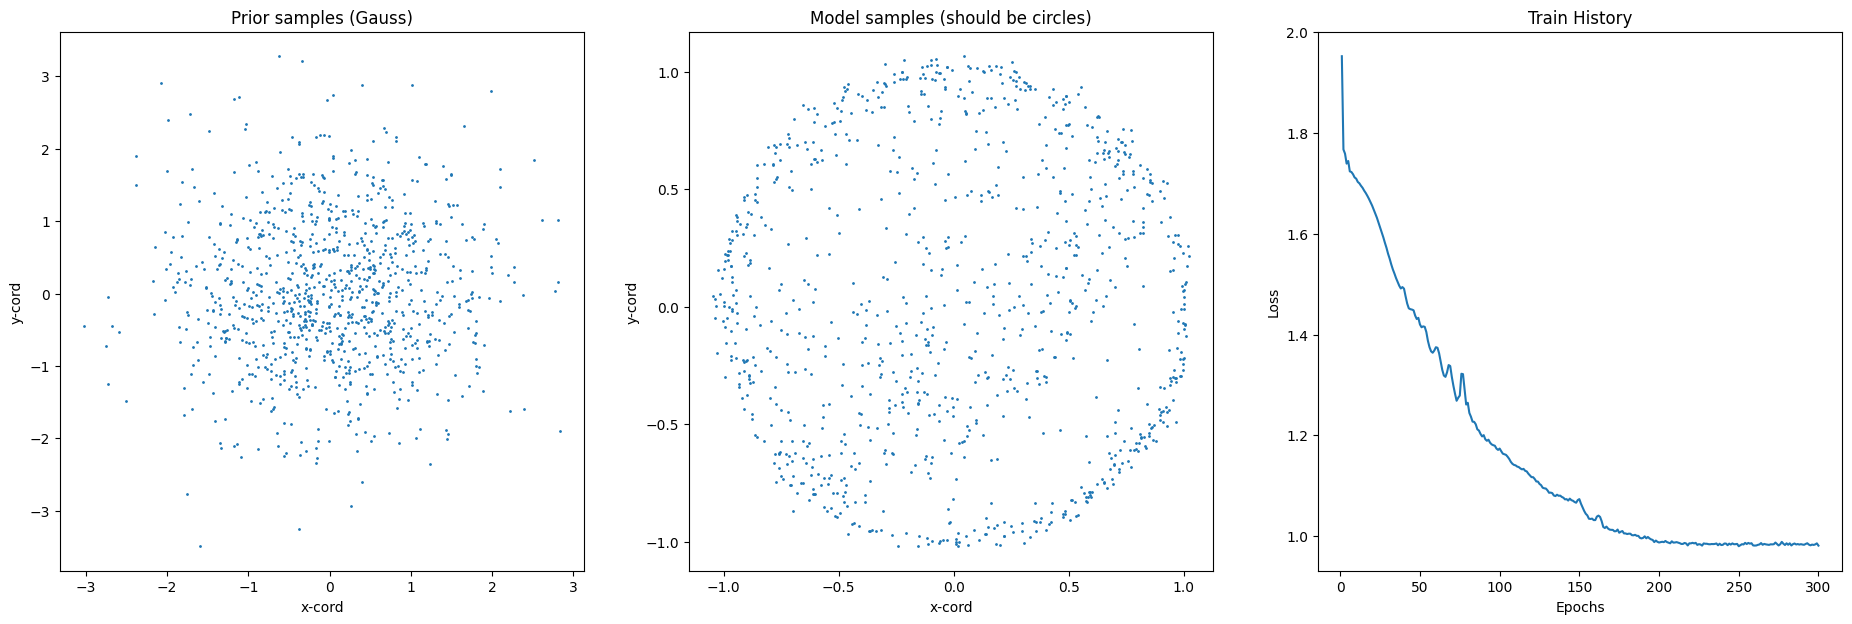

In [65]:
# Plot
fig, ax = plt.subplots(1, 3, figsize=(23, 7))

# Start Distribution
ax[0].scatter(gauss_np_circle[:, 0], gauss_np_circle[:, 1], s=1)
ax[0].set_title("Prior samples (Gauss)")
ax[0].set_xlabel("x-cord")
ax[0].set_ylabel("y-cord")

# Learned Distribution
ax[1].scatter(samples_np_circle[:, 0], samples_np_circle[:, 1], s=1)
ax[1].set_title("Model samples (should be circles)")
ax[1].set_xlabel("x-cord")
ax[1].set_ylabel("y-cord")

# Train Loss
ax[2].plot(range(1, len(train_history_circle)+1), train_history_circle)
ax[2].set_title("Train History")
ax[2].set_ylabel("Loss")
ax[2].set_xlabel("Epochs")

### 6.2 Moon Model Evalutaion

In [66]:
# Evaluation Moon
# create samples
samples_moon, gauss_points_moon = sample(model_moon, 1000, t_start, t_end, solver, 5000, device)

# make numpy arrays for plotting
samples_np_moon = samples_moon.cpu().numpy()       # shape (1000, 2)
gauss_np_moon = gauss_points_moon.cpu().numpy()    # shape (1000, 2)

Text(0.5, 0, 'Epochs')

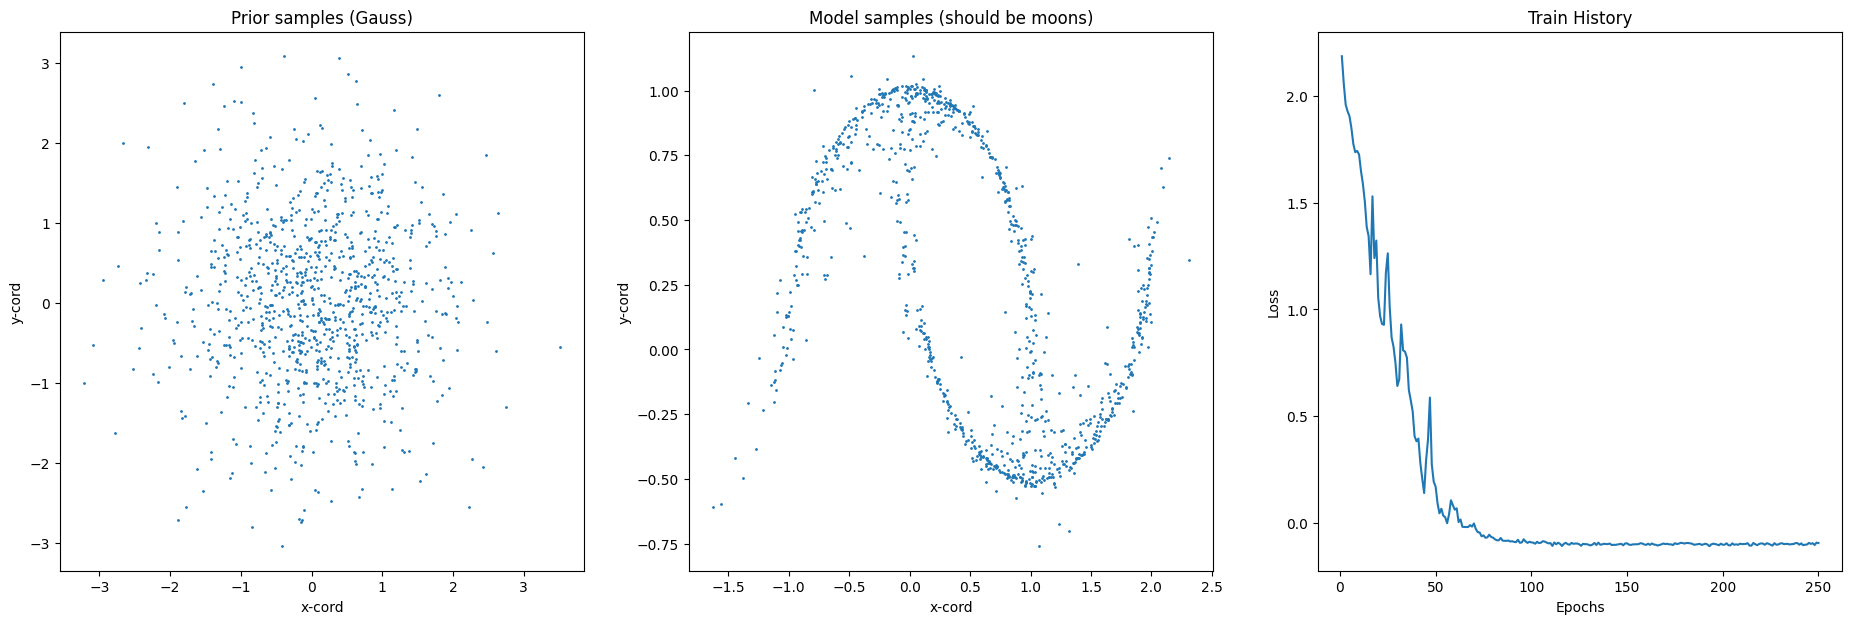

In [67]:
# Plot Moon
fig, ax = plt.subplots(1, 3, figsize=(23, 7))

# Start Distribution
ax[0].scatter(gauss_np_moon[:, 0], gauss_np_moon[:, 1], s=1)
ax[0].set_title("Prior samples (Gauss)")
ax[0].set_xlabel("x-cord")
ax[0].set_ylabel("y-cord")

# Learned Distribution
ax[1].scatter(samples_np_moon[:, 0], samples_np_moon[:, 1], s=1)
ax[1].set_title("Model samples (should be moons)")
ax[1].set_xlabel("x-cord")
ax[1].set_ylabel("y-cord")

# Train Loss
ax[2].plot(range(1, len(train_history_moon)+1), train_history_moon)
ax[2].set_title("Train History")
ax[2].set_ylabel("Loss")
ax[2].set_xlabel("Epochs")